## Explore

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

In [ ]:
df = pd.read_csv("diabetes.csv")

df.head()

,id,'preg','plas','pres','skin','insu','mass','pedi','age','class'
0,1,6,148,72,35,0,33.6,0.627,50,tested_positive
1,2,1,85,66,29,0,26.6,0.351,31,tested_negative
2,3,8,183,64,0,0,23.3,0.672,32,tested_positive
3,4,1,89,66,23,94,28.1,0.167,21,tested_negative
4,5,0,137,40,35,168,43.1,2.288,33,tested_positive


In [ ]:
df.tail()

,id,'preg','plas','pres','skin','insu','mass','pedi','age','class'
763,764,10,101,76,48,180,32.9,0.171,63,tested_negative
764,765,2,122,70,27,0,36.8,0.340,27,tested_negative
765,766,5,121,72,23,112,26.2,0.245,30,tested_negative
766,767,1,126,60,0,0,30.1,0.349,47,tested_positive
767,768,1,93,70,31,0,30.4,0.315,23,tested_negative


In [ ]:
df.shape

(768, 10)

In [ ]:
df.shape[0]

768

In [ ]:
df.size

7680

In [ ]:
df.columns

Index(['id', ''preg'', ''plas'', ''pres'', ''skin'', ''insu'', ''mass'',
       ''pedi'', ''age'', ''class''],
      dtype='object')

In [ ]:
df.loc[:, ["'mass'", "'age'"]]

,'mass','age'
0,33.6,50
1,26.6,31
2,23.3,32
3,28.1,21
4,43.1,33
...,...,...
763,32.9,63
764,36.8,27
765,26.2,30
766,30.1,47


In [ ]:
df["'class'"].value_counts()

,count
'class',
tested_negative,500
tested_positive,268


In [ ]:
df["'class'"].value_counts() / len(df)

,count
'class',
tested_negative,0.651042
tested_positive,0.348958


In [ ]:
pd.crosstab(df["'age'"], df["'class'"])

'class',tested_negative,tested_positive
'age',,
21,58,5
22,61,11
23,31,7
24,38,8
25,34,14
26,25,8
27,24,8
28,25,10
29,16,13


In [ ]:
df.rename(columns={
    "'preg'": "preg",
    "'plas'": "plas",
    "'pres'": "pres",
    "'skin'": "skin",
    "'insu'": "insu",
    "'mass'": "mass",
    "'pedi'": "pedi",
    "'age'": "age",
    "'class'": "class"
}, inplace=True)

In [ ]:
df.columns

Index(['id', 'preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age',
       'class'],
      dtype='object')

Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      768 non-null    int64  
 1   preg    768 non-null    int64  
 2   plas    768 non-null    int64  
 3   pres    768 non-null    int64  
 4   skin    768 non-null    int64  
 5   insu    768 non-null    int64  
 6   mass    768 non-null    float64
 7   pedi    768 non-null    float64
 8   age     768 non-null    int64  
 9   class   768 non-null    object 
dtypes: float64(2), int64(7), object(1)
memory usage: 60.1+ KB


In [ ]:
df.isna().sum()

,0
id,0
preg,0
plas,0
pres,0
skin,0
insu,0
mass,0
pedi,0
age,0
class,0


In [ ]:
df.nunique()

,0
id,768
preg,17
plas,136
pres,47
skin,51
insu,186
mass,248
pedi,517
age,52
class,2


In [ ]:
df["class"] = df["class"].map({
    "tested_negative": 0,
    "tested_positive": 1
})

In [ ]:
df["class"].unique()

array([1, 0])

In [ ]:
cols = ["plas", "pres", "skin", "insu", "mass"]

print((df[cols] == 0).sum())

plas      5
pres     35
skin    227
insu    374
mass     11
dtype: int64


<Axes: >

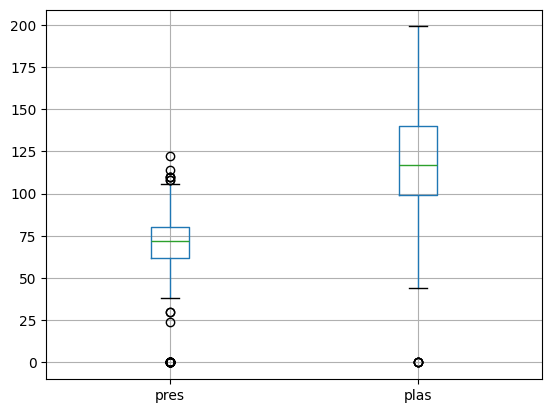

In [ ]:
df.boxplot(column=["pres", "plas"])

<Axes: >

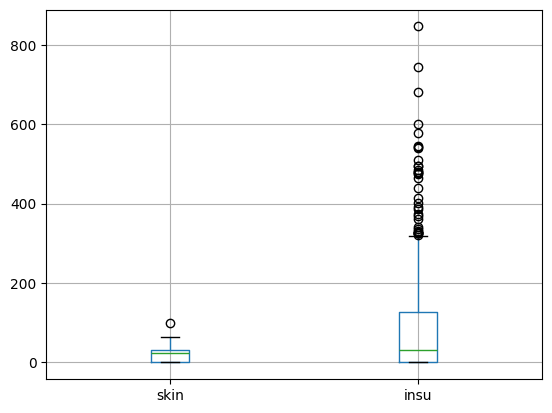

In [ ]:
df.boxplot(column=["skin", "insu"])

<Axes: >

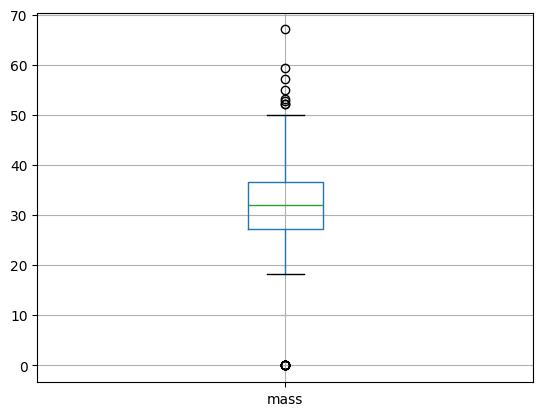

In [ ]:
df.boxplot(column=["mass"])

In [ ]:
Q1 = df["insu"].quantile(0.25)
Q3 = df["insu"].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["insu"] = df["insu"].clip(lower, upper)

<Axes: >

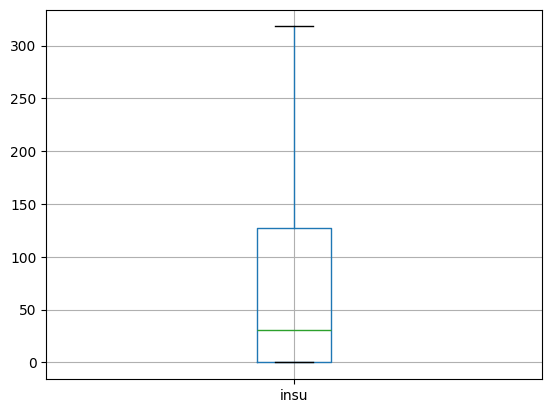

In [ ]:
df.boxplot(column=["insu"])

In [ ]:
df.drop("id", axis=1, inplace=True)

In [ ]:
df.columns

Index(['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class'], dtype='object')

Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,preg,plas,pres,skin,insu,mass,pedi,age,class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,73.652669,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,93.576029,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,318.125000,67.100000,2.420000,81.000000,1.000000


In [ ]:
df.to_csv("cleann Data.csv", index=False)

In [ ]:
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0.0,33.6,0.627,50,1
1,1,85,66,29,0.0,26.6,0.351,31,0
2,8,183,64,0,0.0,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


# Data Visualization

<Axes: xlabel='class', ylabel='count'>

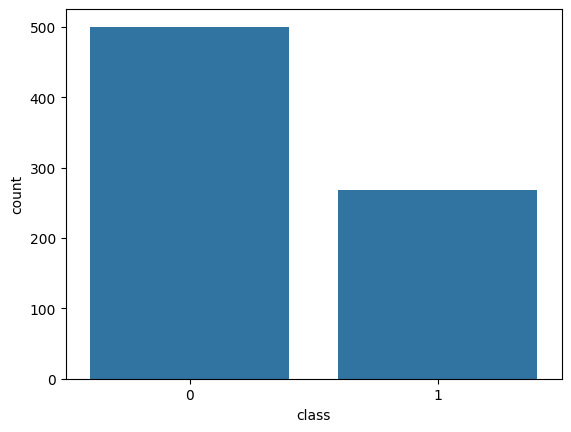

In [ ]:
sb.countplot(x="class", data=df)

In [ ]:
plt.show()

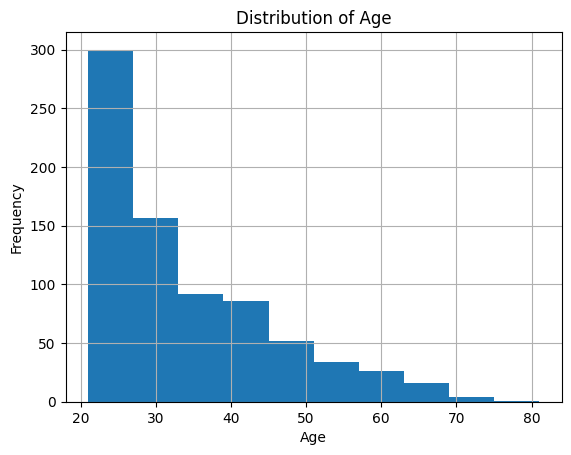

In [ ]:
df["age"].hist()

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

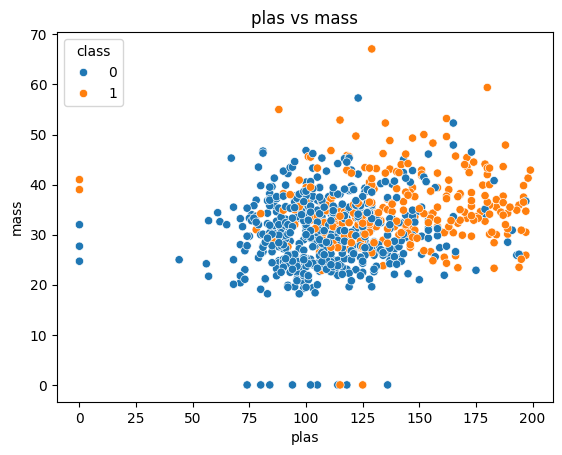

In [ ]:
sb.scatterplot(x="plas", y="mass", hue="class", data=df)

plt.title("plas vs mass")

plt.show()

### Model

In [ ]:
df = pd.read_csv("cleann Data.csv")

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop("class", axis=1), df["class"], test_size=0.2, random_state=0)

In [ ]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = log_reg.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.8181818181818182
